In [1]:
import os
import torch
import numpy as np
import pandas as pd
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv
from torch_geometric.data import Data
from sklearn.metrics import accuracy_score, roc_curve, auc, roc_auc_score, classification_report, confusion_matrix
import seaborn as sns
from sklearn.preprocessing import label_binarize
from copy import deepcopy
from sklearn.utils.class_weight import compute_class_weight

[HAMI-core Msg(80640:140645348638016:libvgpu.c:837)]: Initializing.....
[HAMI-core Msg(80640:140645348638016:libvgpu.c:856)]: Initialized


In [2]:
class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

In [3]:
def local_train(model, data, optimizer, loss_fn, local_epochs=1):
    model.train()
    for _ in range(local_epochs):
        optimizer.zero_grad()
        out = model(data)
        loss = loss_fn(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()
    return model.state_dict()

In [4]:
def evaluate(model, data, mask):
    model.eval()
    with torch.no_grad():
        out = model(data)
        loss = loss_fn(out[mask], data.y[mask]).item()
        pred = out.argmax(dim=1)
        acc = (pred[mask] == data.y[mask]).sum() / mask.sum()
    return loss, acc.item()

In [5]:
def evaluate_on_test(model, data):
    model.eval()
    with torch.no_grad():
        out = model(data)
        if out.isnan().any():
            print("Model output contains NaNs")
            return float("nan")
        if data.test_mask.sum() == 0:
            print("Test mask is empty")
            return float("nan")
        pred = out.argmax(dim=1)
        acc = (pred[data.test_mask] == data.y[data.test_mask]).sum() / data.test_mask.sum()
    return acc.item()

In [6]:
def fedavg(state_dicts):
    avg_state = deepcopy(state_dicts[0])
    for key in avg_state:
        for i in range(1, len(state_dicts)):
            avg_state[key] += state_dicts[i][key]
        avg_state[key] = avg_state[key] / len(state_dicts)
    return avg_state

In [7]:
data_path = "federated_data"
client_ids = ["client1", "client2", "client3", "client4", "client5"]
client_graphs = []

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
for cid in client_ids:
    path = os.path.join(data_path, cid, "knn_k5_los_data.pt")
    graph = torch.load(path).to(device)
    client_graphs.append(graph)

/tmp/ipykernel_80640/2947992221.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  graph = torch.load(path).to(device)


In [10]:
test_graph = torch.load(os.path.join(data_path, "test", "knn_k5_los_data.pt")).to(device)

/tmp/ipykernel_80640/1996089326.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  test_graph = torch.load(os.path.join(data_path, "test", "knn_k5_los_data.pt")).to(device)

In [11]:
in_channels = client_graphs[0].num_node_features
out_channels = client_graphs[0].y.max().item() + 1
hidden_channels = 64
global_model = GraphSAGE(in_channels, hidden_channels, out_channels).to(device)
# loss_fn = torch.nn.CrossEntropyLoss()

train_labels = []
for data in client_graphs:
    train_labels.append(data.y[data.train_mask])
all_train_labels = torch.cat(train_labels).cpu().numpy()

classes = np.unique(all_train_labels)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=all_train_labels)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)


In [12]:
num_rounds = 100
local_epochs = 10
lr = 1e-4

val_acc_per_round = []
val_loss_per_round = []
test_acc_list = []

for rnd in range(1, num_rounds + 1):
    local_states = []
    val_accuracies = []
    val_losses = []

    print(f"\n--- Round {rnd} ---")

    for i, data in enumerate(client_graphs):
        local_model = deepcopy(global_model)
        optimizer = torch.optim.Adam(local_model.parameters(), lr=lr, weight_decay=5e-4)
        state_dict = local_train(local_model, data, optimizer, loss_fn, local_epochs)
        local_states.append(state_dict)

        val_loss, val_acc = evaluate(local_model, data, data.val_mask)
        val_accuracies.append(val_acc)
        val_losses.append(val_loss)
        print(f"  [Client {i+1}] Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # FedAvg
    new_state = fedavg(local_states)
    global_model.load_state_dict(new_state)

    # Evaluate global model on shared test graph
    test_acc = evaluate_on_test(global_model, test_graph)
    test_acc_list.append(test_acc)

    avg_val_acc = sum(val_accuracies) / len(val_accuracies)
    avg_val_loss = sum(val_losses) / len(val_losses)

    val_acc_per_round.append(avg_val_acc)
    val_loss_per_round.append(avg_val_loss)

    print(f"[Round {rnd:02d}] Avg Val Loss: {avg_val_loss:.4f} | Avg Val Acc: {avg_val_acc:.4f}")
    print(f"[Round {rnd:02d}] Global Test Accuracy: {test_acc:.4f}")


--- Round 1 ---
  [Client 1] Val Loss: 1.1165 | Val Acc: 0.3247
  [Client 2] Val Loss: 1.1242 | Val Acc: 0.3314
  [Client 3] Val Loss: 1.1181 | Val Acc: 0.3306
  [Client 4] Val Loss: 1.1214 | Val Acc: 0.3306
  [Client 5] Val Loss: 5.4828 | Val Acc: 0.3529
[Round 01] Avg Val Loss: 1.9926 | Avg Val Acc: 0.3340
[Round 01] Global Test Accuracy: 0.3293

--- Round 2 ---
  [Client 1] Val Loss: 1.0725 | Val Acc: 0.4166
  [Client 2] Val Loss: 1.0770 | Val Acc: 0.3484
  [Client 3] Val Loss: 1.0641 | Val Acc: 0.3336
  [Client 4] Val Loss: 1.0669 | Val Acc: 0.3484
  [Client 5] Val Loss: 3.4699 | Val Acc: 0.3877
[Round 02] Avg Val Loss: 1.5501 | Avg Val Acc: 0.3669
[Round 02] Global Test Accuracy: 0.3624

--- Round 3 ---
  [Client 1] Val Loss: 1.0404 | Val Acc: 0.4700
  [Client 2] Val Loss: 1.0476 | Val Acc: 0.4033
  [Client 3] Val Loss: 1.0289 | Val Acc: 0.4136
  [Client 4] Val Loss: 1.0389 | Val Acc: 0.4136
  [Client 5] Val Loss: 2.9559 | Val Acc: 0.4433
[Round 03] Avg Val Loss: 1.4224 | Avg Val

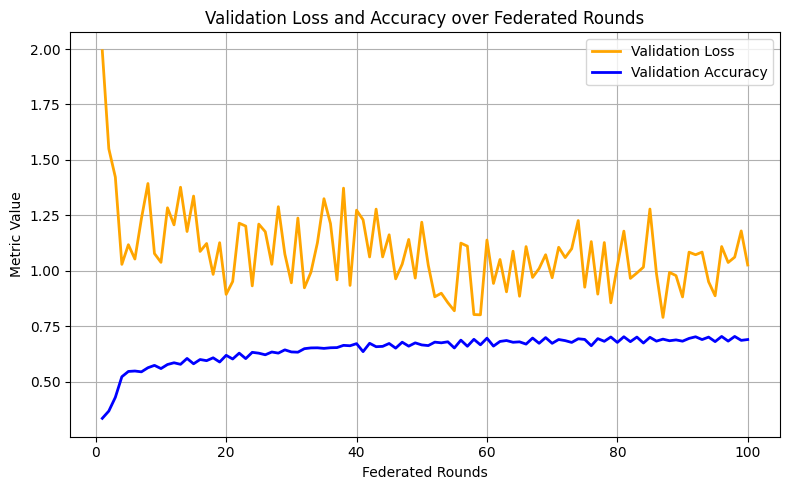

In [13]:
import matplotlib.pyplot as plt

rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(8, 5))
plt.plot(rounds, val_loss_per_round, label='Validation Loss', color='orange', linewidth=2)
plt.plot(rounds, val_acc_per_round, label='Validation Accuracy', color='blue', linewidth=2)

plt.xlabel("Federated Rounds")
plt.ylabel("Metric Value")
plt.title("Validation Loss and Accuracy over Federated Rounds")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
def predict_on_test(model, data):
    model.eval()
    with torch.no_grad():
        logits = model(data)
        test_logits = logits[data.test_mask]
        y_true = data.y[data.test_mask].cpu().numpy()
        y_pred = test_logits.argmax(dim=1).cpu().numpy()
        y_score = torch.softmax(test_logits, dim=1).cpu().numpy()
    return y_true, y_pred, y_score


In [15]:
class_names=["Short", "Medium", "Long"]
y_true, y_pred, y_score = predict_on_test(global_model, test_graph)


--- Classification Report (Global Model on Test Graph) ---
              precision    recall  f1-score   support

           0     0.8178    0.7380    0.7758      4568
           1     0.4409    0.4401    0.4405      2161
           2     0.6870    0.8688    0.7673      1700

    accuracy                         0.6880      8429
   macro avg     0.6486    0.6823    0.6612      8429
weighted avg     0.6948    0.6880    0.6881      8429



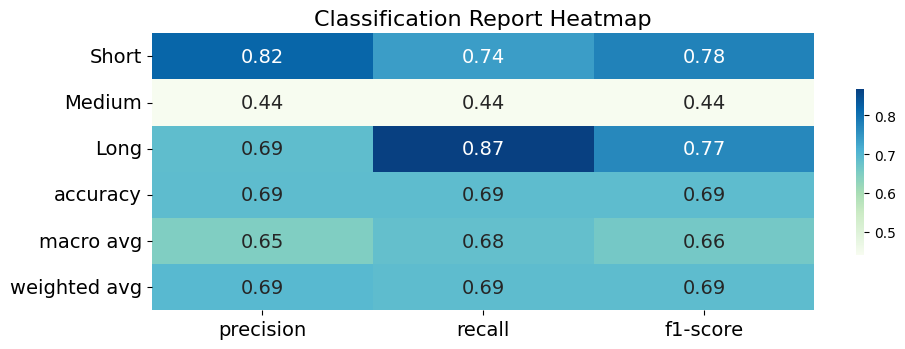

In [16]:
print("\n--- Classification Report (Global Model on Test Graph) ---")
print(classification_report(y_true, y_pred, digits=4))
report_dict = classification_report(
    y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0
)
df = pd.DataFrame(report_dict).T
df = df.drop(columns=["support"])


plt.figure(figsize=(10, len(df) * 0.6))
sns.heatmap(df, annot=True, cmap="GnBu", fmt=".2f",
        annot_kws={"size": 14}, 
            cbar_kws={"shrink": 0.6})
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title("Classification Report Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

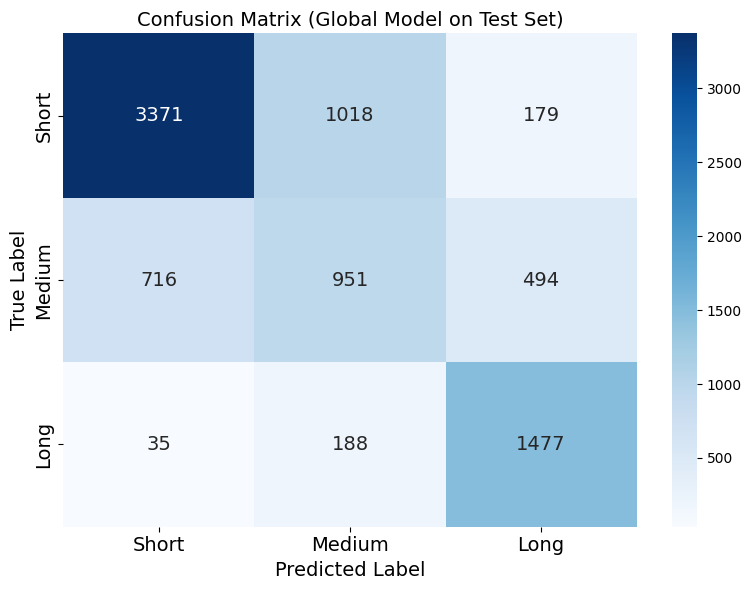

In [17]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                     xticklabels=class_names, yticklabels=class_names,
                     annot_kws={"size": 14})
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Short", "Medium", "Long"])
# disp.plot(cmap='Blues', values_format='d', ax=ax)

plt.title("Confusion Matrix (Global Model on Test Set)", fontsize=14)
ax.set_xlabel("Predicted Label", fontsize=14)
ax.set_ylabel("True Label", fontsize=14)
ax.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.show()

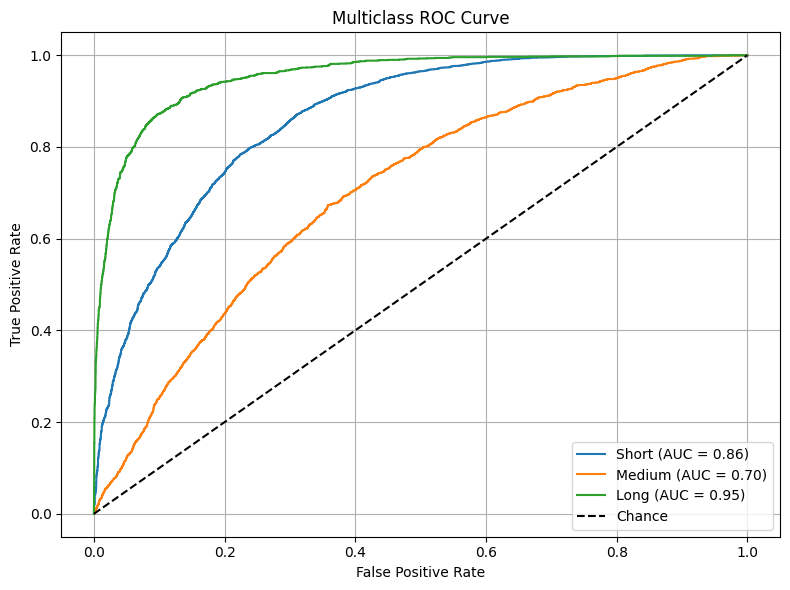

Macro-Average AUC: 0.8395
Weighted AUC: 0.8397


In [18]:
y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
n_classes = len(class_names)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

macro_auc = roc_auc_score(y_true_bin, y_score, average="macro")
print(f"Macro-Average AUC: {macro_auc:.4f}")


weighted_auc = roc_auc_score(y_true_bin, y_score, average="weighted")
print(f"Weighted AUC: {weighted_auc:.4f}")